<a href="https://colab.research.google.com/github/anigopalan/Basic-Agentic-AI-for-Math-computation/blob/main/PhishingURLDetectionML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Scope of Project:
Given phishing URLs, a machine learning model using logistic regression will be able to identify whether it is benign or malicious. The goal is to use a Character-Level TF-IDF.

In [1]:
import pandas as pd
import numpy as np
import re

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt

# Data Aquistion & Project Objective

In [2]:
df = pd.read_csv("phishing_site_urls.csv")

# Map labels
df['Label'] = df['Label'].map({'good': 0, 'bad': 1})

# Drop missing
df = df.dropna(subset=['URL', 'Label'])

# Phase 2:
 Data Preparation and Exploration


# Clean URLs

In [3]:
def clean_url(url):
    url = url.lower()
    url = re.sub(r'[^a-z0-9:/?.&=%-]', '', url)
    return url

df['URL'] = df['URL'].astype(str).apply(clean_url)

# Define Features and Labels

In [4]:
X = df['URL']
y = df['Label']

# Train/Test Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Build ML Pipeline (Vectorization + Model)

In [6]:
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        analyzer='char',
        ngram_range=(3,6),
        max_features=8000
    )),
    ('clf', LogisticRegression(
        max_iter=1000,
        class_weight='balanced'
    ))
])

# Train Baseline Model

In [7]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(analyzer='char', max_features=8000,
                                 ngram_range=(3, 6))),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

# Evaluate Model

In [8]:
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

Classification Report:
              precision    recall  f1-score   support

         0.0       0.93      0.97      0.95      9621
         1.0       0.98      0.96      0.97     16857

    accuracy                           0.96     26478
   macro avg       0.96      0.96      0.96     26478
weighted avg       0.96      0.96      0.96     26478

Confusion Matrix:
[[ 9287   334]
 [  696 16161]]
ROC-AUC Score: 0.992667630267891


# Plot ROC Curve

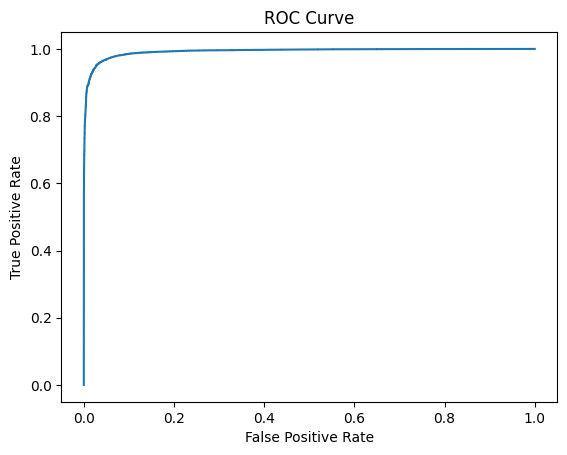

In [9]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

# Hyperparamater Tuning

In [10]:
param_grid = {
    'tfidf__ngram_range': [(3,5), (3,6)],
    'tfidf__max_features': [5000, 8000],
    'clf__C': [0.1, 1, 10]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'clf__C': 10, 'tfidf__max_features': 8000, 'tfidf__ngram_range': (3, 5)}


# Evaluate Tuned Model

In [11]:
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

         0.0       0.94      0.97      0.95      9621
         1.0       0.98      0.96      0.97     16857

    accuracy                           0.97     26478
   macro avg       0.96      0.97      0.96     26478
weighted avg       0.97      0.97      0.97     26478

ROC-AUC: 0.994392506549326


# Final Results and Next Steps

The model achieved strong overall performance after hyperparameter tuning, with an accuracy of 97% and an exceptionally high ROC-AUC score of approximately 0.994, indicating that the classifier has excellent capability in distinguishing between phishing and legitimate URLs. The phishing class (class 1) shows a precision of 0.98, meaning that when the model flags a URL as malicious, it is correct 98% of the time, which is very desirable for minimizing false alarms. The recall for the phishing class is 0.96, indicating that the model successfully detects 96% of phishing URLs, with a relatively small false negative rate. From a cybersecurity perspective, this is a strong detection balance since the system both captures most attacks and maintains low unnecessary blocking of legitimate websites.




Potential improvements could focus on enhancing adversarial robustness and feature richness. One direction is incorporating additional lexical and statistical URL features such as character distribution ratios, domain structure metrics, and query parameter analysis to capture more behavioral signals beyond n-gram patterns.